**Normalization** refers to rescaling numeric feature values so they fall into a well-defined, proportional range (typically $[0, 1]$ or $[-1, 1]$) without distorting differences in ranges of values.

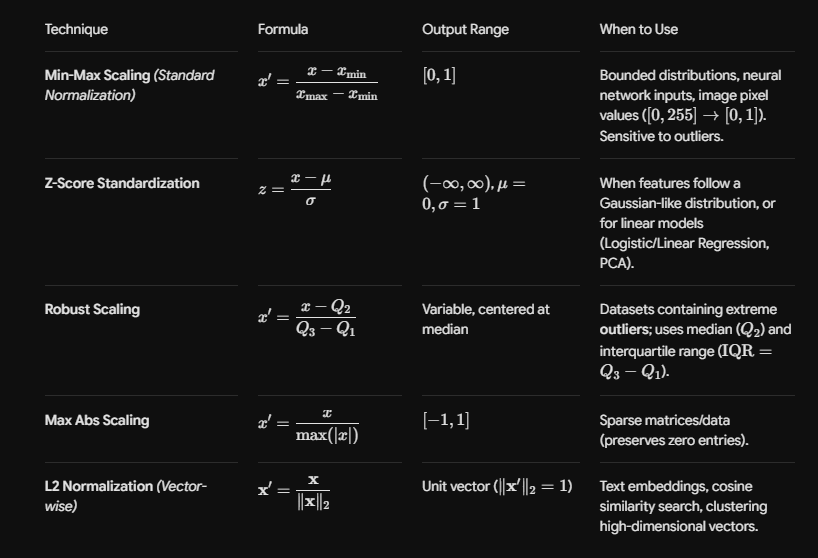

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [36]:
df = pd.read_csv("wine_data.csv" , header = None, usecols=[0,1,2])

In [37]:
df

,0,1,2
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


In [38]:
df.columns = ['class label', 'Alcohol', 'Malic Acid']

In [39]:
df

,class label,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

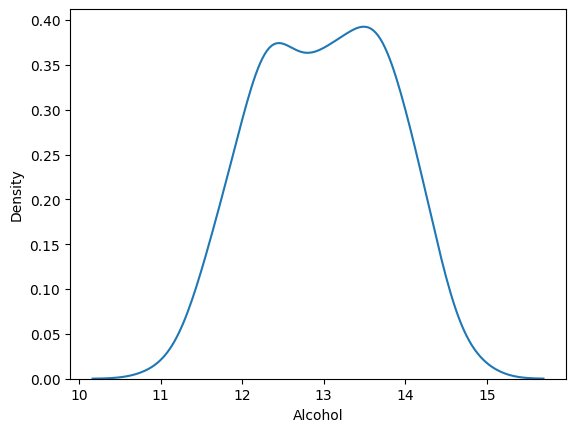

In [40]:
sns.kdeplot(df['Alcohol'])

alcohol 10 to 15
density 0.00 to 0.35

<Axes: xlabel='Malic Acid', ylabel='Density'>

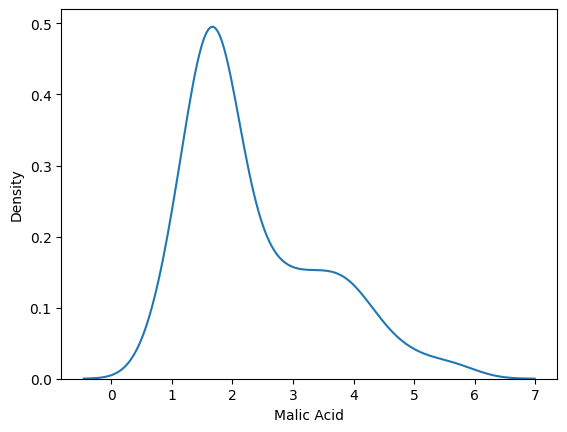

In [41]:
sns.kdeplot(df['Malic Acid'])

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

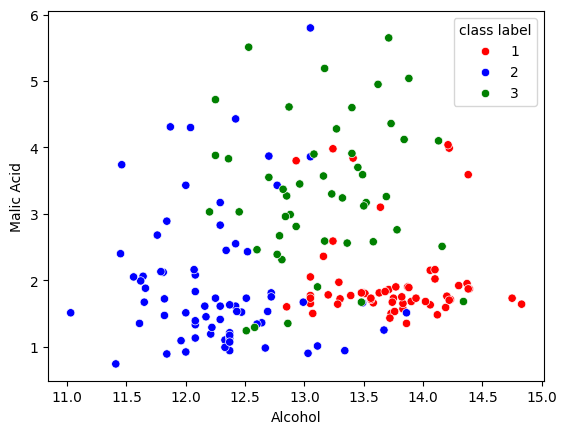

In [42]:
# Map all present classes with integer keys
color_dict = {
    1: 'red',
    2: 'blue',
    3: 'green'
}

sns.scatterplot(
    data=df,
    x='Alcohol',
    y='Malic Acid',
    hue='class label',
    palette=color_dict
)

In [43]:
from sklearn.model_selection import train_test_split
X_train , X_test ,Y_train, Y_test = train_test_split(df.drop('class label', axis = 1), df['class label'], test_size = 0.3)
X_train.shape , X_test.shape


((124, 2), (54, 2))

**MinMaxScaler**

In [44]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  X_train_scaled and X_test_scaled are new variable for MinMAxScaled data


In [45]:
X_train_scaled

array([[0.53157895, 0.23625255],
       [0.21315789, 0.        ],
       [0.44473684, 0.17515275],
       [0.74473684, 0.12627291],
       [0.36578947, 0.7209776 ],
       [0.83947368, 0.63136456],
       [0.64736842, 0.15682281],
       [0.48421053, 0.75763747],
       [0.53157895, 0.17922607],
       [0.11315789, 0.58044807],
       [0.53157895, 0.17107943],
       [0.42368421, 0.09572301],
       [0.83157895, 0.14256619],
       [0.25526316, 0.12627291],
       [0.64736842, 0.54989817],
       [0.45789474, 0.51731161],
       [0.27631579, 0.24236253],
       [0.75      , 0.84521385],
       [0.70526316, 0.19755601],
       [0.43157895, 0.01832994],
       [0.73947368, 0.65784114],
       [0.88157895, 0.19959267],
       [0.50789474, 0.52138493],
       [0.62368421, 0.61507128],
       [0.32105263, 0.78004073],
       [0.57105263, 0.18126273],
       [0.33157895, 0.39511202],
       [0.63684211, 0.57230143],
       [0.15263158, 0.09368635],
       [0.27631579, 0.19144603],
       [0.

In [46]:
X_test_scaled

array([[ 0.41315789,  0.3197556 ],
       [ 0.75526316,  0.16089613],
       [ 0.20789474,  0.16904277],
       [ 0.52631579,  0.00203666],
       [ 0.73421053,  0.17515275],
       [ 0.72368421,  0.3808554 ],
       [ 0.56052632,  0.299389  ],
       [ 0.38947368,  0.17107943],
       [ 0.74736842,  0.20570265],
       [ 0.61315789,  0.3401222 ],
       [ 0.43684211,  0.13034623],
       [ 0.16052632,  0.23828921],
       [ 0.16578947,  0.20162933],
       [ 0.33157895,  0.10590631],
       [ 0.25526316,  0.51731161],
       [ 0.56315789,  0.34623218],
       [ 0.65      ,  0.18737271],
       [ 0.70526316,  0.9694501 ],
       [ 0.36578947,  0.14663951],
       [ 0.35263158,  0.0101833 ],
       [ 0.22105263,  0.69653768],
       [ 0.86052632,  0.20977597],
       [ 0.66578947,  0.17107943],
       [ 0.56315789,  0.87576375],
       [ 0.53157895,  0.15478615],
       [ 0.3       ,  0.11405295],
       [ 0.83947368,  0.16496945],
       [ 0.21315789,  0.40733198],
       [ 0.68684211,

Standardization, Normalization er MIN max er j operation gula , oi gula korar por , actually amder numpy array akare dei , so aita k pandas dataframe e convert kore nite hoi ,

In [47]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [48]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.3,0.1
50%,0.5,0.2
75%,0.7,0.4
max,1.0,1.0


In [49]:
np.round(X_test_scaled.describe(), 1)

,Alcohol,Malic Acid
count,54.0,54.0
mean,0.5,0.3
std,0.2,0.2
min,0.1,-0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.4
max,0.9,1.0


Text(0.5, 1.0, 'After Scaling')

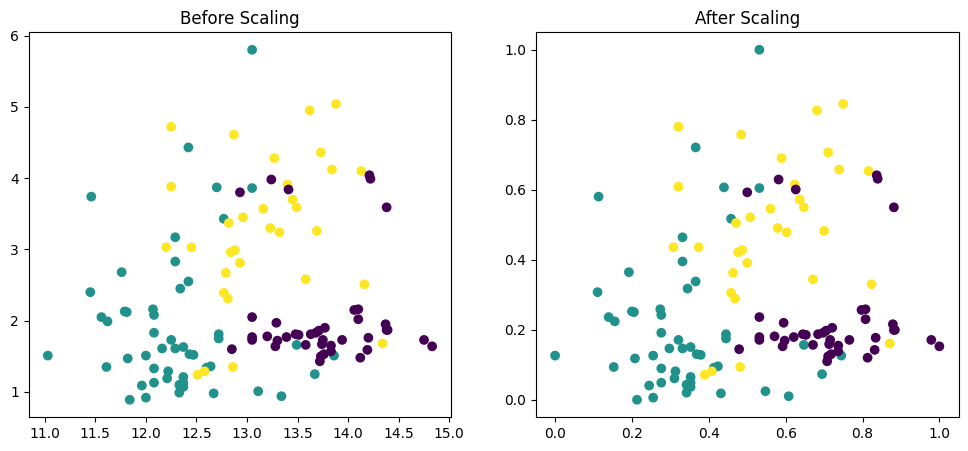

In [50]:
fig, (ax1 , ax2) = plt.subplots(ncols = 2, figsize = (12,5))

ax1.scatter(X_train['Alcohol'], X_train['Malic Acid'], c = Y_train)
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic Acid'], c= Y_train)
ax2.set_title('After Scaling')

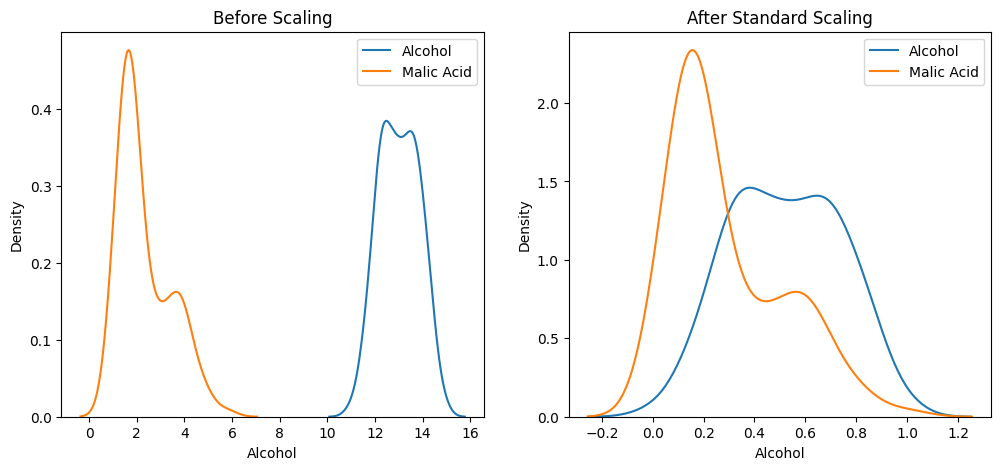

In [51]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1, label='Alcohol')
sns.kdeplot(X_train['Malic Acid'], ax=ax1, label='Malic Acid')
ax1.legend()

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2, label='Alcohol')
sns.kdeplot(X_train_scaled['Malic Acid'], ax=ax2, label='Malic Acid')
ax2.legend()

plt.show()

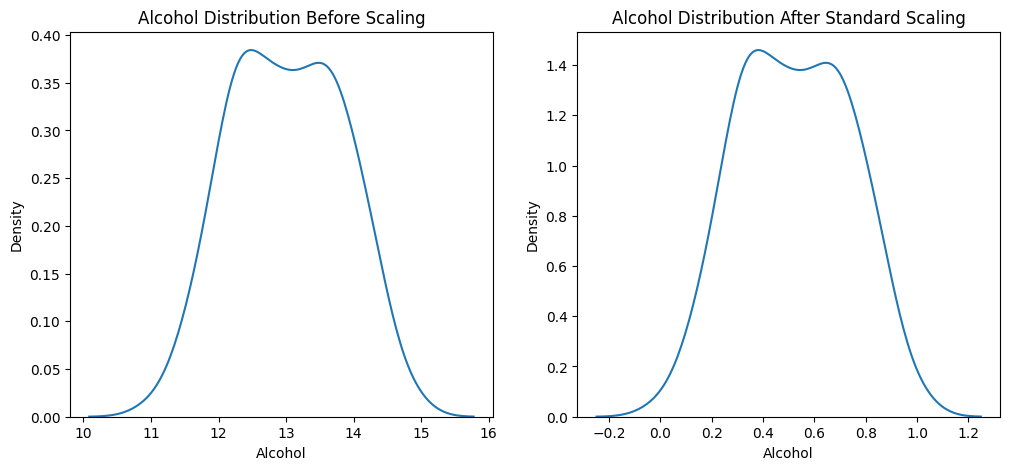

In [52]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

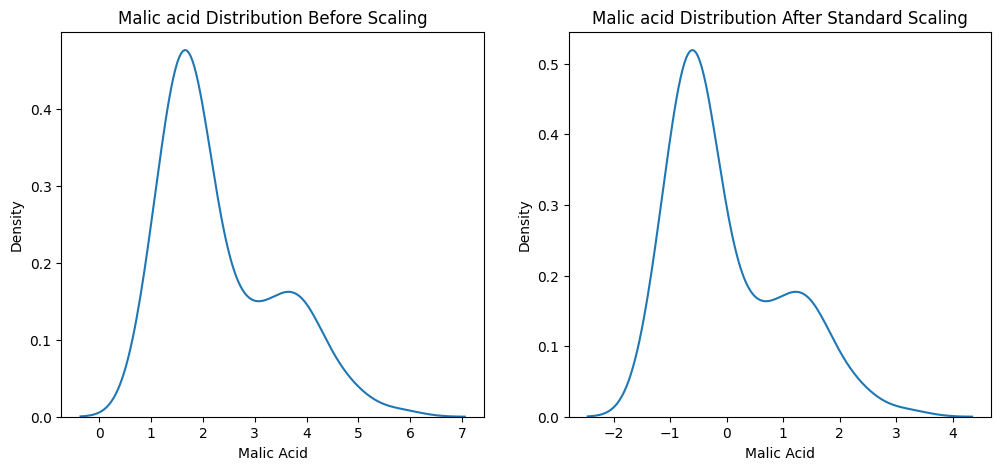

In [55]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic Acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Malic Acid'], ax=ax2)
plt.show()

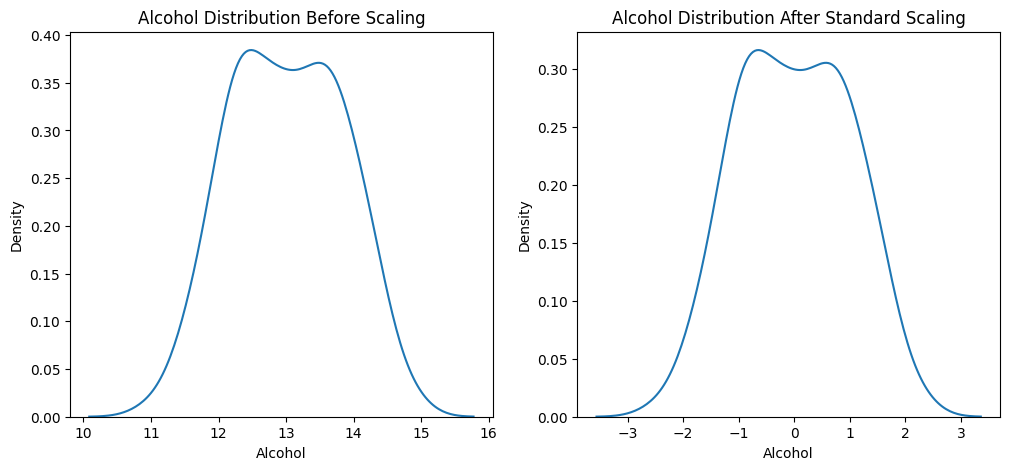

In [53]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ১. Standard Scaling করা
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# ২. আবার DataFrame-এ রূপান্তর (কলাম নাম বজায় রাখার জন্য)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# ৩. এবার প্লট প্রদর্শন
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# After scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)

plt.show()